<a href="https://colab.research.google.com/github/raisauw/demodua/blob/main/2311102205_2311102233_VISKOM_11_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tahap ini menginstall library Roboflow ke environment Colab

In [ ]:
!pip install roboflow

Tahap ini dicopy langsung dari Roboflow untuk login dengan API key dan ambil
dataset

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="EFxXfM2lrYpBjPy6jKFU")
project = rf.workspace("raifankas-workspace").project("trash-eeqam-8hklk")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...


Import library untuk operasi file, lalu list semua file dan folder di dalam folder dataset, tampilkan struktur lengkap beserta contoh 3 file pertama di setiap folder

In [ ]:
import os

# cek folder
dataset_location = dataset.location
print("Dataset location:", dataset_location)
print("\nFolder contents:")
for item in os.listdir(dataset_location):
    print(f"  - {item}")

# cek structure
print("\nDetailed structure:")
for root, dirs, files in os.walk(dataset_location):
    level = root.replace(dataset_location, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:  # show 3 file pertama
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... dan {len(files) - 3} file lainnya')

Dataset location: /content/trash-1

Folder contents:
  - README.dataset.txt
  - README.roboflow.txt
  - test
  - train
  - valid

Detailed structure:
trash-1/
  README.dataset.txt
  README.roboflow.txt
  test/
    Kaca/
      glass_bottle-228-_png.rf.451767537750cecdf3b08c0622fce1ce.jpg
      glass_bottle-57-_png.rf.15a585e702b498bb4540d5bce76b7db6.jpg
      recyclable_004361_photo_jpg.rf.73ceb21b01d5ff9cb8d36934c0b79c46.jpg
      ... dan 7 file lainnya
    Organik/
      IMG_0750_JPG.rf.430359e98bbad593604dac8ad57f5b00.jpg
      daun-39-_jpg.rf.7f9b01d3ec7399865fede2539c8a6924.jpg
      food_waste-25-_png.rf.e2a6ad5446cac2b56b626ea87582570c.jpg
      ... dan 9 file lainnya
    Logam/
      aerosol-33-_png.rf.ae9e79dcc22a93fb722b15ea0501231b.jpg
      R_1639_jpg.rf.0f08074d84cb301c766b0439afef295e.jpg
      metal216_jpg.rf.ec5b21e86efc971b6d7f3b4f5e5c7a31.jpg
      ... dan 6 file lainnya
    Kertas/
      cardboard-145-_jpg.rf.3073540affe9ebee3849d56e04b59357.jpg
      cardboard-404-_j

Load gambar dari folder, Set ukuran gambar target (224×224 piksel) dan jumlah gambar per batch saat training (32 gambar sekaligus). Setelah itu, definisikan path ke masing-masing folder train, validasi, dan test. Normalisasi setiap nilai piksel (0–255) dibagi 255  menjadi rentang 0-1. Load gambar dari folder train, resize otomatis ke 224×224 shuffle=True agar urutan gambar diacak tiap epoch kecuali val & test

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN_PATH = '/content/trash-1/train'
VAL_PATH   = '/content/trash-1/valid'
TEST_PATH  = '/content/trash-1/test'

# Normalisasi pixel 0-255 to 0-1
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Kelas:", train_generator.class_indices)
print(f"Train: {train_generator.samples} gambar")
print(f"Validation: {val_generator.samples} gambar")
print(f"Test: {test_generator.samples} gambar")

Found 617 images belonging to 5 classes.
Found 176 images belonging to 5 classes.
Found 87 images belonging to 5 classes.
Kelas: {'Kaca': 0, 'Kertas': 1, 'Logam': 2, 'Organik': 3, 'Plastik': 4}
Train: 617 gambar
Validation: 176 gambar
Test: 87 gambar


Import MobileNetV2, load MobileNetV2 yang sudah dilatih pada gambar ImageNet, buang head klasifikasinya. Setelah itu, freeze layer MobileNetV2. MobileNetV2 sebagai feature extractor, ubah output 7x7x1280 menjadi vektor 1280, layer fully connected, 128 neuron, matikan 30% neuron secara random saat training, output 5 kelas, softmax = probabilitas

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet' # transfer learning
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')  # 5 kelas
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training 20 epoch, metrik accuracy dipantau saat training, pantau performa di data validasi tiap epoch, hasil tiap epoch disimpan di history

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6613 - loss: 0.8936 - val_accuracy: 0.8295 - val_loss: 0.3890
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.8882 - loss: 0.3042 - val_accuracy: 0.9148 - val_loss: 0.2536
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9514 - loss: 0.1607 - val_accuracy: 0.9205 - val_loss: 0.2304
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9822 - loss: 0.0857 - val_accuracy: 0.9261 - val_loss: 0.2274
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9919 - loss: 0.0559 - val_accuracy: 0.9432 - val_loss: 0.2129
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9919 - loss: 0.0503 - val_accuracy: 0.9148 - val_loss: 0.2405
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9951 - loss: 0.0373 - val_accuracy: 0.9034 - val_loss: 0.2352
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9984 - loss: 0.0277 - val_accuracy: 0.9148 - val_loss:

Buat grafik accuracy train vs validasi per epoch, evaluasi model

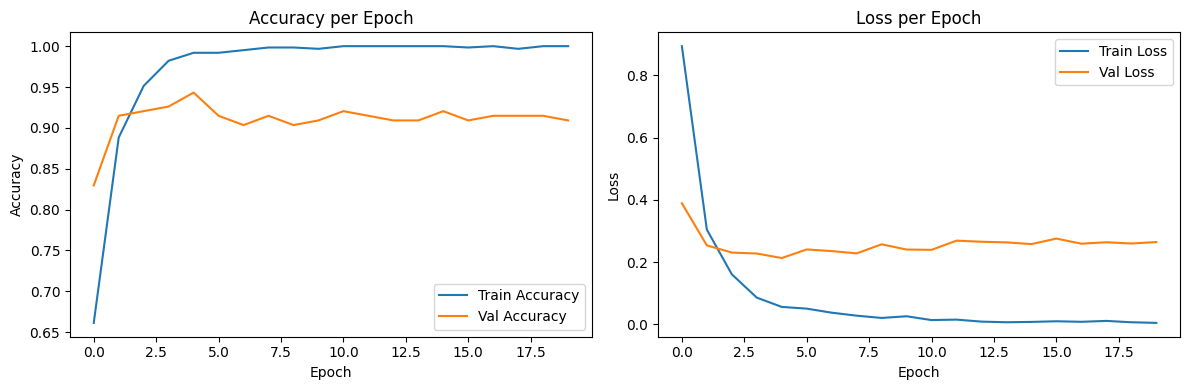

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9310 - loss: 0.2010

Test Accuracy: 93.10%
Test Loss: 0.2010


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

loss, acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {acc*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

Buat confusion matrix, evaluasi precision, recall, dan F1-score

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step

Classification Report:
              precision    recall  f1-score   support

        Kaca       0.90      0.90      0.90        10
      Kertas       0.96      0.96      0.96        24
       Logam       0.89      0.89      0.89         9
     Organik       1.00      0.92      0.96        12
     Plastik       0.91      0.94      0.92        32

    accuracy                           0.93        87
   macro avg       0.93      0.92      0.93        87
weighted avg       0.93      0.93      0.93        87



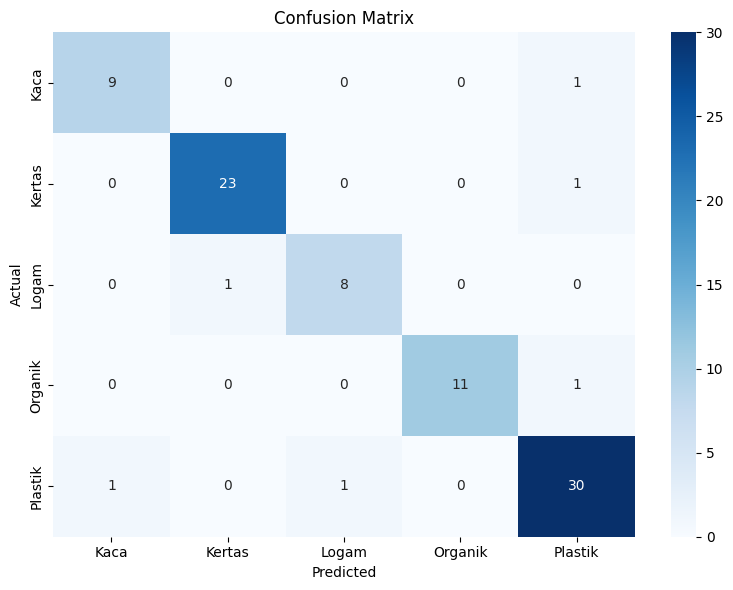

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()